[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Projects/project_5_boston/project_5_starter.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Project 5 — What is it worth, and how sure are you?
## Starter: neighbourhood valuation with a defensible interval

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

**Goal.** Value five named census tracts for a municipal valuation office; establish whether the nonlinearity in this data is real or decorative; attach to each valuation an interval you would defend in an appeal hearing.

Read `README.md` in this folder first — it is the brief, and it lists the numbers your memo must contain.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

ISLP not installed; using CSV / URL fallbacks.


## The data

506 census tracts, twelve predictors, one target. `medv` is the tract's **median owner-occupied
home value in \$1,000s** — so `21.6` means \$21,600. The office wants `medv` for five specific
tracts, so every tract needs a stable identifier — and that identifier has to be the *same* one
on every machine.

Two details make that less automatic than it looks. The CSV carries the tract id in its first
column, so we load with `index_col=0` to keep it out of the predictor matrix (forget it and the id
comes in as a thirteenth "predictor"). But `load()` returns the **ISLP package's** copy of this
data when ISLP is installed — as it is on Colab, where the setup cell installs it — and that copy
labels the same 506 rows from `0`, where the CSV labels them from `1`. Same rows, same order, same
columns; different labels. So we re-label positionally with `reset_index(drop=True)` immediately
after loading: the index is then the tract's **row number, counted from 0**, on every machine, and
every tract number quoted below means the same tract for everyone.

In [2]:
Boston = load('Boston', index_col=0)

# load() returns the ISLP package's frame when ISLP is installed (as on Colab) and
# the bundled CSV otherwise; the two label rows differently (0-based vs 1-based).
# Same rows, same order -- so re-label positionally and every tract number below
# means the same tract on every machine.
Boston = Boston.reset_index(drop=True)

print('shape :', Boston.shape)
print('index :', Boston.index.min(), '...', Boston.index.max(),
      '(unique:', Boston.index.is_unique, ')')
Boston.head()

shape : (506, 13)
index : 0 ... 505 (unique: True )


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
TARGET = 'medv'
y = Boston[TARGET]
X = Boston.drop(columns=TARGET)

print('predictors:', list(X.columns))
print()
print(y.describe().round(3).to_string())

predictors: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']

count    506.000
mean      22.533
std        9.197
min        5.000
25%       17.025
50%       21.200
75%       25.000
max       50.000


### First look at the target

One picture. Look at it properly before moving on — the shape of this distribution is the single
fact that most constrains what the office can honestly publish, and it is worth a sentence in
your memo (requirement 7 in the brief).

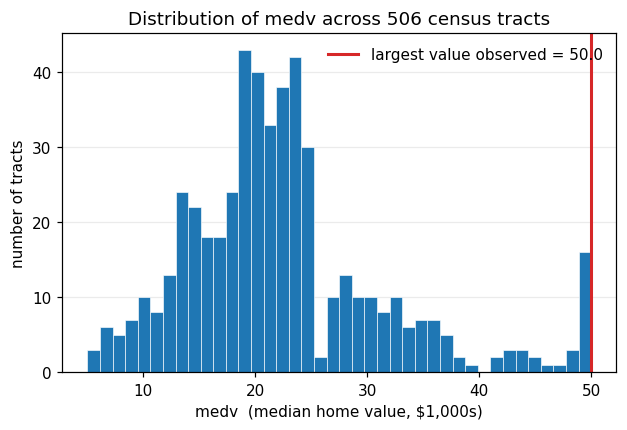

range of medv     : 5.0 to 50.0  ($1,000s)
tracts at the top : 16 of 506 sit exactly at 50.0 (3.2% of the data)


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(y, bins=40, color='C0', edgecolor='white', linewidth=0.4)
ax.axvline(y.max(), color='C3', linewidth=2,
           label=f'largest value observed = {y.max():.1f}')
ax.set(xlabel='medv  (median home value, $1,000s)', ylabel='number of tracts',
       title='Distribution of medv across 506 census tracts')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.show()

n_at_max = int((y == y.max()).sum())
print(f'range of medv     : {y.min():.1f} to {y.max():.1f}  ($1,000s)')
print(f'tracts at the top : {n_at_max} of {len(y)} sit exactly at {y.max():.1f} '
      f'({100 * n_at_max / len(y):.1f}% of the data)')

## The two reference figures

These are the numbers quoted in the brief. They are computed here on **all 506 tracts**, so that
they are one fixed public number, identical for everyone and independent of anybody's split —
they exist so you can confirm that your basis expansion and your folds are set up the same way
ours are. They are a **pipeline check, not a model choice**: every decision you make from Step 1
onwards is made on the training tracts only.

In [5]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

FOLDS = KFold(n_splits=5, shuffle=True, random_state=2024)

def cv_rmse(model, Xd, yd, cv=FOLDS):
    """Mean 5-fold CV RMSE in $1,000s, plus the per-fold scores.

    Use the same `cv` object for every model you compare, so the folds are identical."""
    scores = -cross_val_score(model, Xd, yd, cv=cv,
                              scoring='neg_root_mean_squared_error')
    return scores.mean(), scores

linear_ref = LinearRegression()
spline_ref = make_pipeline(SplineTransformer(n_knots=5, degree=3), LinearRegression())

ref_lin, folds_lin = cv_rmse(linear_ref, X, y)
ref_spl, folds_spl = cv_rmse(spline_ref, X, y)

print(f'reference | linear, all 12 predictors    : CV RMSE ${ref_lin:.2f}k')
print(f'reference | cubic-spline basis, 5 knots  : CV RMSE ${ref_spl:.2f}k')
print(f'reference | improvement                  : '
      f'{100 * (ref_lin - ref_spl) / ref_lin:.1f}%')
print()
print('per fold, linear :', np.round(folds_lin, 2))
print('per fold, spline :', np.round(folds_spl, 2))

reference | linear, all 12 predictors    : CV RMSE $4.92k
reference | cubic-spline basis, 5 knots  : CV RMSE $4.58k
reference | improvement                  : 7.1%

per fold, linear : [4.61 5.07 5.57 5.25 4.13]
per fold, spline : [3.98 6.87 4.62 3.63 3.79]


## The held-out set — sealed until the end

A fixed 80/20 split, seeded. **Do not touch `X_test` or `y_test`** — do not plot them, do not
summarise them, do not fit on them — until you call the evaluation helper at the very end.
Everything you decide, you decide by cross-validating on the 404 training tracts.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024)

print(f'training tracts : {len(X_train)}')
print(f'held-out tracts : {len(X_test)}   <-- sealed until the final evaluation')

training tracts : 404
held-out tracts : 102   <-- sealed until the final evaluation


## The five tracts the office is asking about

Chosen in advance: one from the cheap end of the market, three through the middle, one from the
very top. All five are in the **held-out** set — which is the point. Nobody, your model included,
has seen what they are worth. Their predictors are printed below; their `medv` values live in
`y_test` and stay sealed until Step 5.

In [7]:
FIVE_TRACTS = [400, 112, 1, 296, 161]   # row numbers in the re-labelled frame above
assert all(t in X_test.index for t in FIVE_TRACTS), 'the five tracts must be held out'

X_five = X_test.loc[FIVE_TRACTS]
print('the five tracts to value (predictors only -- their medv is sealed):')
X_five

the five tracts to value (predictors only -- their medv is sealed):


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
400,25.04610,0.0,18.10,0,0.693,5.987,100.0,1.5888,24,666,20.2,26.77
112,0.12329,0.0,10.01,0,0.547,5.913,92.9,2.3534,6,432,17.8,16.21
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
296,0.05372,0.0,13.92,0,0.437,6.549,51.0,5.9604,4,289,16.0,7.39
161,1.46336,0.0,19.58,0,0.605,7.489,90.8,1.9709,5,403,14.7,1.73


## The baseline you must try to beat

Multiple linear regression on all twelve predictors, 5-fold CV **on the training tracts only**.
This is the number a flexible model has to improve on to justify itself. A flexible model that
does not beat it is a finding, not a failure — report it as one.

In [8]:
from sklearn.dummy import DummyRegressor

null_cv, _ = cv_rmse(DummyRegressor(strategy='mean'), X_train, y_train)
base_cv, base_folds = cv_rmse(LinearRegression(), X_train, y_train)

print(f'null model (training mean only)   : CV RMSE ${null_cv:.2f}k')
print(f'BASELINE  linear, all predictors  : CV RMSE ${base_cv:.2f}k   <-- beat this')
print()
print('per fold :', np.round(base_folds, 2))

null model (training mean only)   : CV RMSE $9.00k
BASELINE  linear, all predictors  : CV RMSE $4.89k   <-- beat this

per fold : [4.79 4.38 4.47 5.65 5.18]


## The evaluation helper — call it once, at the end

Everyone's final number is computed by the same function, so the numbers are comparable. Pass it
your point estimates and the two ends of your 95% intervals for **all** held-out tracts, aligned
with `X_test.index`. It reports how accurate the point estimates were **and what your intervals
actually did**: the fraction of held-out tracts they in fact contained, and how wide they had to
be to manage it. An interval is a claim about the future; this is that claim being checked.

Call it **once**. If you call it repeatedly while tuning, you have turned the held-out set into a
validation set and your number is no longer honest — if that happens, say so in the memo.

In [9]:
MEDV_CAP = float(y.max())   # the largest value medv ever takes anywhere in this data

def evaluate_on_test(name, point, lower, upper, y_true=None, show_tracts=True):
    """Score point estimates and 95% intervals on the held-out tracts.

    name   : label for this run, e.g. 'natural spline in lstat and rm'
    point  : predicted medv, array-like aligned with X_test.index (or a Series)
    lower  : lower end of each 95% interval, same alignment
    upper  : upper end of each 95% interval, same alignment
    y_true : leave as None for the sealed held-out set -- the honest choice. Pass
             y_train only to see the output format without spending the test set.
    """
    against = ('HELD-OUT test set' if y_true is None
               else 'custom target (NOT the held-out set)')
    truth = y_test if y_true is None else pd.Series(y_true)
    idx = truth.index
    point, lower, upper = (pd.Series(np.asarray(v, dtype=float).ravel(), index=idx)
                           for v in (point, lower, upper))

    err = truth - point
    rmse = float(np.sqrt((err ** 2).mean()))
    mae = float(err.abs().mean())
    inside = (truth >= lower) & (truth <= upper)
    width = upper - lower
    over_cap = int((upper > MEDV_CAP).sum())

    print(f'=== {name} ===')
    print(f'evaluated against : {against}   (n = {len(idx)})')
    print(f'test RMSE         : ${rmse:.3f}k')
    print(f'test MAE          : ${mae:.3f}k')
    print(f'interval coverage : {100 * inside.mean():.1f}%  '
          f'({int(inside.sum())} of {len(idx)} tracts inside)   [nominal 95%]')
    print(f'mean width        : ${width.mean():.2f}k  '
          f'(median ${width.median():.2f}k, narrowest ${width.min():.2f}k, '
          f'widest ${width.max():.2f}k)')
    print(f'intervals whose upper end exceeds {MEDV_CAP:.1f} : {over_cap}')

    if show_tracts and all(t in idx for t in FIVE_TRACTS):
        table = pd.DataFrame({'point': point[FIVE_TRACTS].round(2),
                              'lower': lower[FIVE_TRACTS].round(2),
                              'upper': upper[FIVE_TRACTS].round(2),
                              'width': width[FIVE_TRACTS].round(2),
                              'actual': truth[FIVE_TRACTS],
                              'inside': inside[FIVE_TRACTS]})
        print()
        print('the five tracts:')
        print(table.to_string())

    return {'name': name, 'rmse': rmse, 'mae': mae,
            'coverage': float(inside.mean()),
            'mean_width': float(width.mean()), 'over_cap': over_cap}

In [10]:
# Format demo only: a deliberately useless "model" -- guess the training median, +/- 10 --
# scored against the TRAINING tracts, so the held-out set stays sealed.
_p = np.full(len(y_train), y_train.median())
_ = evaluate_on_test('FORMAT DEMO -- median guess +/- 10, on training rows',
                     _p, _p - 10, _p + 10, y_true=y_train, show_tracts=False)

=== FORMAT DEMO -- median guess +/- 10, on training rows ===
evaluated against : custom target (NOT the held-out set)   (n = 404)
test RMSE         : $9.075k
test MAE          : $6.435k
interval coverage : 79.2%  (320 of 404 tracts inside)   [nominal 95%]
mean width        : $20.00k  (median $20.00k, narrowest $20.00k, widest $20.00k)
intervals whose upper end exceeds 50.0 : 0


---

# Your work starts here

Six steps. Add code and markdown cells under each heading. The brief (`README.md`) lists the
numbers your memo must contain; these steps are the route to them.

## Step 1 — Confirm the reference figures, then look at the residuals

The two reference numbers above are yours to check, not to trust. Then fit the baseline linear
model on the training tracts and look at where it goes wrong: residuals against fitted values,
and residuals against each predictor in turn. You are looking for **systematic curvature in the
residual mean**, which is the Chapter 3 diagnostic for a missing nonlinear term.

*Chapter 3 — residual diagnostics.* Two or three predictors should stand out. Note which.

## Step 2 — Establish that the curvature is real

A residual plot is suggestive; it is not evidence a valuation office can cite in a hearing. Turn
the suggestion into a statistic. Any of these routes is legitimate:

- a **nested $F$-test** — add quadratic and cubic terms in the suspect predictors to the linear
  model and test the added block (`statsmodels`, `anova_lm`); Chapter 3;
- a **cross-validated comparison** on the training folds between the linear model and one with a
  flexible term in the suspect predictors only; Chapter 5;
- a **spline or GAM** in one predictor, reading off the shape of the smooth or its effective
  degrees of freedom; Chapter 7.

Then the harder question, which is where the marks are: the reference basis expansion spends
flexibility on **all twelve** predictors. Is it earned everywhere, or only somewhere? Run your
test on a predictor you do *not* believe is curved, and report that result too. A finding of the
form "curved here, flat there" is worth far more than "the data is nonlinear".

*Chapters 3, 5 and 7.*

## Step 3 — Choose your model on the training tracts

Compare candidates on the same `FOLDS`, with `cv_rmse`, using `X_train, y_train` only. Sensible
candidates: the linear baseline; a transformation of one or two predictors; a spline or polynomial
basis in the curved predictors with everything else left linear; the blanket spline basis; a GAM
(`pygam`). Keep a small table of candidate against CV RMSE — it belongs in the memo.

Two things to watch. First, read the **per-fold** scores, not only the mean: a model that wins on
average and collapses on one fold is not a model you want to defend in a hearing. Second, a wide
basis expansion of correlated predictors can be badly ill-conditioned; if a candidate behaves
erratically from fold to fold, that is usually why, and Chapter 6's ridge penalty is the fix.

*Chapters 5, 6 and 7.*

## Step 4 — Value the five tracts, with an interval

Fit your chosen model on all 404 training tracts and produce, for each of tracts
**400, 112, 1, 296 and 161**, a point estimate and a **95% interval**.

Then answer, in writing, the question the office actually asked: **what is your interval an
interval for?** The office is not asking about tracts in general, or about the average tract of
this description. It is asking about *tract 161* — one tract, one number, one hearing. Be precise
about which quantity your interval covers, and satisfy yourself that this is the quantity under
dispute. Chapter 3's closing formula sheet ("Key formulas at a glance") sets the two candidate
intervals side by side; they differ by one symbol, and what they promise differs by a great deal
more than that.

*Chapter 3 — intervals. In `statsmodels`, `get_prediction(...).summary_frame()` returns both
kinds and names them; `sklearn` returns neither, so if your model is an `sklearn` pipeline you
must construct the interval yourself and say how.*

## Step 5 — Evaluate once

Compute point estimates and both interval ends for **all** held-out tracts with your final model,
then call `evaluate_on_test(...)` exactly once. Read the coverage line carefully and compare it
with the 95% you nominally promised. If the two disagree, the memo must explain why — that gap is
the most informative number in this project.

## Step 6 — The memo

Replace the template below with your own. One page. Numbers, not adjectives.

---

## MEMO — Assessed median values for five census tracts

**To:** Municipal Valuation Office  ·  **From:** *your name*  ·  **Date:** *date*

**Recommendation.** *(one or two sentences: which model produced the published figures, and
whether you consider its interval defensible)*

**Model selection.** Linear baseline, 5-fold CV RMSE on the training tracts: *\$…k*. Chosen
model: *…*, CV RMSE *\$…k*, an improvement of *…%*. Reference figures over all 506 tracts:
linear *\$…k*, spline basis *\$…k*.

**Is the curvature real?** *(the statistic, its value, its $p$-value or CV gap; which predictors
carry the curvature, and which do not)*

**Assessed values.**

| Tract | Point estimate (\$k) | Interval lower | Interval upper | Width |
|---|---|---|---|---|
| 400 | | | | |
| 112 | | | | |
| 1 | | | | |
| 296 | | | | |
| 161 | | | | |

**What kind of interval this is, and why.** *(one sentence naming the interval; one saying why it
is the quantity the office needs rather than the other one)*

**Held-out performance.** Test RMSE *\$…k*; the intervals covered *…%* of held-out tracts against
a nominal 95%; mean width *\$…k*.

**The top of the range.** *(one sentence on the range of `medv` and what it implies for any
interval whose upper end runs past it)*

**Caveats.** *(where the model should not be trusted; which of the five figures you are least
confident in; what would change the recommendation)*